In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

import cv2
import numpy as np
import matplotlib.pyplot as plt
# import tensorflow as tf
# from tensorflow.keras import layers,models
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
# image_path  = "C:/Users/mifth/OneDrive/Desktop/Thesis/Data/cbisben/Mass-Training_P_00018_RIGHT_MLO.png"
image_path  = "E:/4th Year/Thesis/Data/Malignant/22580098.png"
image = cv2.imread(image_path)

In [3]:
def preprocess_image(image_path):
    # target_size=(256, 256)
   
    images = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    
    # Resize the image
    image = cv2.resize(images, (256, 256))

    
    #image = cv2.GaussianBlur(image, (5, 5), 0)

    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image_eq = clahe.apply(image)
    
   
    gamma = 1.5
    image_gamma = np.uint8(cv2.pow(image_eq / 255.0, gamma) * 255)
    
    return image_gamma



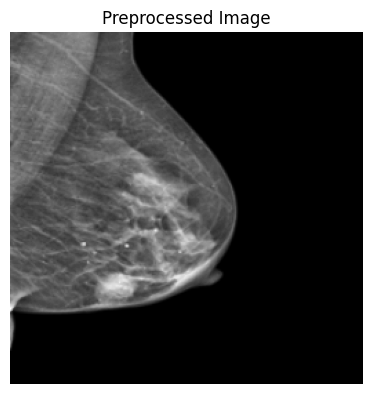

In [4]:
preprocessed_image= preprocess_image(image_path)
# original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(10, 5))

# # Plot the original image
# plt.subplot(1, 2, 1)
# plt.imshow(original_image, cmap='gray')
# plt.title('Original Image')
# plt.axis('off')

# Plot the preprocessed image
plt.subplot(1, 2, 2)
plt.imshow(preprocessed_image, cmap='gray')
plt.title('Preprocessed Image')
plt.axis('off')

plt.show()

In [5]:
import cv2
import numpy as np

def extract_roi(preprocessed_image):
    
    _, binary_image = cv2.threshold(preprocessed_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    
    opening = cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, kernel)

    
    contours, _ = cv2.findContours(opening, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    
    if not contours:
        return None

    
    largest_contour = max(contours, key=cv2.contourArea)

    
    x, y, w, h = cv2.boundingRect(largest_contour)

    
    roi = preprocessed_image[y:y+h, x:x+w]

    return roi


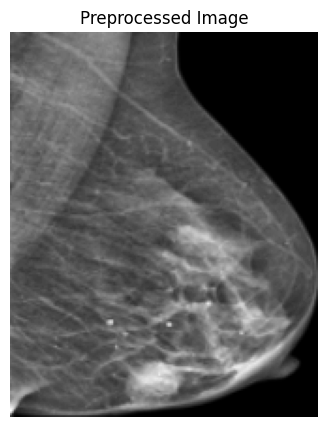

In [6]:
roi_image= extract_roi(preprocessed_image)
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(10, 5))

# # Plot the original image
# plt.subplot(1, 2, 1)
# plt.imshow(original_image, cmap='gray')
# plt.title('Original Image')
# plt.axis('off')

# Plot the preprocessed image
plt.subplot(1, 2, 2)
plt.imshow(roi_image, cmap='gray')
plt.title('Preprocessed Image')
plt.axis('off')

plt.show()

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
from torchvision import models
from PIL import Image
from torchvision.models import resnet50, ResNet50_Weights
from torchvision import transforms

In [8]:
def extract_deep_features(roi, model):
    roi_pil = Image.fromarray(np.uint8(roi)).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    transformed_image = transform(roi_pil)
    input_batch = transformed_image.unsqueeze(0)
    
    model.eval()
    with torch.no_grad():
        features = model(input_batch)
    
    return features.squeeze().numpy()

deep_features_list = []
model = resnet50(weights=ResNet50_Weights.DEFAULT)
model.eval()

roi = extract_roi(preprocess_image(image_path))
deep_features = extract_deep_features(roi, model)
deep_features_list.append(deep_features)

deep_features_array = np.array(deep_features_list)
deep_features_array_flattenedm = deep_features_array.reshape(1, -1)

print("Flattened Deep Features Array Shape:", deep_features_array_flattenedm.shape)



Flattened Deep Features Array Shape: (1, 1000)


In [9]:
import os
import cv2
import numpy as np
import mahotas.features
from scipy.stats import skew
import mahotas

def calculate_mass_roundness(contour):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    roundness = (4 * np.pi * area) / (perimeter ** 2)
    return roundness

def calculate_normalized_radius_properties(contour):
    centroid_x, centroid_y = find_contour_centroid(contour)
    distances = [np.linalg.norm(np.array(point[0]) - np.array([centroid_x, centroid_y])) for point in contour]
    normalized_radius_entropy = -np.sum(np.log(np.array(distances) + 1e-5) / len(distances))
    normalized_radius_variance = np.var(distances)
    return normalized_radius_entropy, normalized_radius_variance

def find_contour_centroid(contour):
    moments = cv2.moments(contour)
    centroid_x = int(moments["m10"] / moments["m00"])
    centroid_y = int(moments["m01"] / moments["m00"])
    return centroid_x, centroid_y

def calculate_roughness(contour):
    hull = cv2.convexHull(contour)
    area_hull = cv2.contourArea(hull)
    area_contour = cv2.contourArea(contour)
    roughness = area_hull / area_contour
    return roughness

def compute_morphological_features(roi_image):
    contours, _ = cv2.findContours(roi_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) > 0:
        contour = max(contours, key=cv2.contourArea)

        area, perimeter = cv2.contourArea(contour), cv2.arcLength(contour, True)
        roundness = calculate_mass_roundness(contour)
        normalized_radius_entropy, normalized_radius_variance = calculate_normalized_radius_properties(contour)
        roughness = calculate_roughness(contour)

        return roundness, normalized_radius_entropy, normalized_radius_variance, roughness
    else:
        return 0,0,0,0


morphological_features_list = []

 
preprocessed_image = preprocess_image(image_path)
    
    
roi = extract_roi(preprocessed_image)

    
roundness, normalized_radius_entropy, normalized_radius_variance, roughness = compute_morphological_features(roi)
    
    
morphological_features_list.append([roundness, normalized_radius_entropy, normalized_radius_variance, roughness])


morphological_features_array = np.array(morphological_features_list)


print(morphological_features_array.shape)
#print(morphological_features_array)


(1, 4)


In [10]:
def extract_texture_features(image):
    
    texture_features = mahotas.features.haralick(image).mean(axis=0)
    return texture_features


all_texture_features = []



    
preprocessed_image = preprocess_image(image_path)
    
    
roi = extract_roi(preprocessed_image)

    
    
texture_features = extract_texture_features(roi)
    
    
all_texture_features.append(texture_features)

all_texture_features_array = np.array(all_texture_features)
print(all_texture_features_array.shape)
#print(all_texture_features_array)


(1, 13)


In [11]:
import os
import cv2
import numpy as np
from scipy.stats import skew

def extract_density_features(image):
    
    hist = cv2.calcHist([image], [0], None, [256], [0, 256]).flatten()
    
    
    mean = np.mean(hist)
    variance = np.var(hist)
    skewness = skew(hist)
    
    return mean, variance, skewness

all_density_features = []

preprocessed_image = preprocess_image(image_path)
    
    
roi = extract_roi(preprocessed_image)

    
    
mean, variance, skewness = extract_density_features(roi)
    
all_density_features.append([mean, variance, skewness])

density_features_array = np.array(all_density_features)
    
    # print(f"Image: {image_file}")
    # print(f"Mean: {mean}")
    # print(f"Variance: {variance}")
    # print(f"Skewness: {skewness}")
    # print("\n")
print(density_features_array.shape)
#print(density_features_array)

(1, 3)


In [12]:
featureb = np.column_stack((deep_features_array_flattenedm,morphological_features_array, all_texture_features_array, density_features_array))
print(featureb.shape)
print(featureb)


(1, 1020)
[[-4.06237155e-01 -1.42517388e-02  2.77999759e-01 ...  1.31328125e+02
   1.82538781e+05  1.09223767e+01]]


In [13]:
import xgboost as xgb

# Load XGBoost model
model = xgb.Booster()
model.load_model("xgb_model.json")

dtest = xgb.DMatrix(featureb.reshape(1, -1))  

y_pred_proba = model.predict(dtest)


y_pred = (y_pred_proba >= 0.5).astype(int)  
print("Predicted label:", y_pred[0]) 


Predicted label: 1
